# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.stats import ttest_ind, norm
from scipy.integrate import quad 

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from core.dgp import RCTs
import core.rct as rct
from core.variables import UnivariateGaussian

# DGP

In [6]:
dgp = RCTs(n_experiments=100, prior_mean=0.1, prior_std=0.1, noise_std=1.0, prior_seed=0)

In [7]:
treated_sample, control_sample = dgp.sample(sample_size=5000, seed=0)

# Estimation

In [16]:
emp_te_arr, _, p_val_arr = rct.difference_in_means(treated_sample, control_sample)

# Selection

In [17]:
significant_selection = rct.select_significant_experiments(treatment_effects=emp_te_arr, p_vals=p_val_arr, alpha=0.05)
threshold_selection = rct.select_above_threshold(treatment_effects=emp_te_arr, p_vals=p_val_arr, threshold=0.0)
largest_selection = rct.select_largest_effects(treatment_effects=emp_te_arr, p_vals=p_val_arr, k=0.1)
bh_selection = rct.select_bh(treatment_effects=emp_te_arr, p_vals=p_val_arr, fdr=0.05)

# Evaluation

In [18]:
significant_val_est = rct.obj_func(significant_selection, emp_te_arr)
significant_val_true = rct.obj_func(significant_selection, dgp.treatment_effects)
significant_wc = significant_val_est - significant_val_true

threshold_val_est = rct.obj_func(threshold_selection, emp_te_arr)
threshold_val_true = rct.obj_func(threshold_selection, dgp.treatment_effects)
threshold_wc = threshold_val_est - threshold_val_true

largest_val_est = rct.obj_func(largest_selection, emp_te_arr)
largest_val_true = rct.obj_func(largest_selection, dgp.treatment_effects)
largest_wc = largest_val_est - largest_val_true

bh_val_est = rct.obj_func(bh_selection, emp_te_arr)
bh_val_true = rct.obj_func(bh_selection, dgp.treatment_effects)
bh_wc = bh_val_est - bh_val_true

result_df = pd.DataFrame({
    'Significant': [significant_val_est, significant_val_true, significant_wc],
    'Threshold': [threshold_val_est, threshold_val_true, threshold_wc],
    'Largest': [largest_val_est, largest_val_true, largest_wc],
    'BH': [bh_val_est, bh_val_true, bh_wc], 
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Significant,Threshold,Largest,BH
Estimated Policy Value,0.154953,0.137535,0.282613,0.312167
True Policy Value,0.149702,0.133387,0.279554,0.324089
Winner's Curse,0.005251,0.004148,0.003059,-0.011923


In [19]:
del dgp, treated_sample, control_sample, emp_te_arr, p_val_arr, significant_selection, threshold_selection, largest_selection, bh_selection
del significant_val_est, significant_val_true, significant_wc, threshold_val_est, threshold_val_true, threshold_wc, largest_val_est, largest_val_true, largest_wc, bh_val_est, bh_val_true, bh_wc

# Winner's Curse

In [20]:
optimization_params = {
    'significant': {
        'optimizer': rct.select_significant_experiments,
        'params': {}, 
        'display_name': 'Significance'
    }, 
    'threshold': {
        'optimizer': rct.select_above_threshold,
        'params': {'threshold': 0.0},
        'display_name': 'Threshold'
    },
    'largest': {
        'optimizer': rct.select_largest_effects,
        'params': {'k': 0.1},
        'display_name': 'Largest'
    },
    'bh': {
        'optimizer': rct.select_bh,
        'params': {'fdr': 0.05},
        'display_name': 'Benjamini-Hochberg'
    }
}

dgp_params = {
    'n_experiments': 100, 
    'prior_mean': 0.1, 
    'prior_std': 0.1,
    'noise_std': 1.0, 
    'prior_seed': 0,
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {}

result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 937 out of 1000 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


In [21]:
for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']
    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / data_params['sample_size'] ** 0.5 

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse: {wc_avg:.4f} ({wc_se:.4f})')


Selection with Significance:
  - Average True Value: 0.1960 (0.0019)
  - Average Estimated Value: 0.3694 (0.0020)
  - Average Winner's Curse: 0.1734 (0.0024)

Selection with Threshold:
  - Average True Value: 0.1329 (0.0006)
  - Average Estimated Value: 0.1857 (0.0014)
  - Average Winner's Curse: 0.0529 (0.0014)

Selection with Largest:
  - Average True Value: 0.2089 (0.0024)
  - Average Estimated Value: 0.4077 (0.0032)
  - Average Winner's Curse: 0.1988 (0.0034)

Selection with Benjamini-Hochberg:
  - Average True Value: nan (nan)
  - Average Estimated Value: nan (nan)
  - Average Winner's Curse: nan (nan)


# Estimating Winner's Curse

In [22]:
dgp = RCTs(**dgp_params)
treated_sample, control_sample = dgp.sample(sample_size=data_params['sample_size'], seed=0)

## Standard Bootstrap

In [23]:
boot_wc_dstn_dict = rct.get_wc_boot_dstn(
    treated_sample=treated_sample, control_sample=control_sample, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 937 out of 1000 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


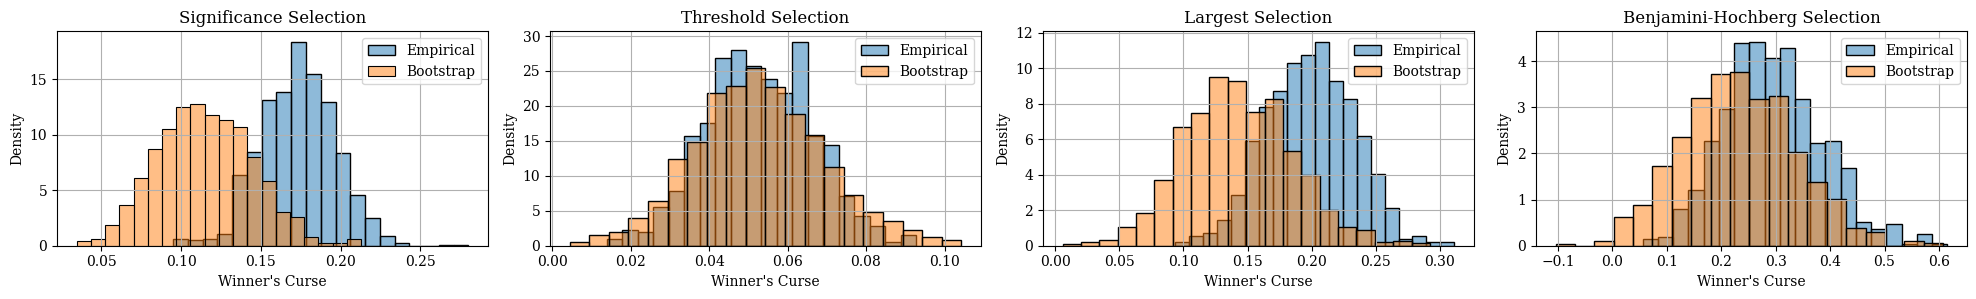

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3.09))

for i, optimizer_name in enumerate(optimization_params.keys()):
    display_name = optimization_params[optimizer_name]['display_name']
    
    wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
    wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

    sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=axes[i])
    sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=axes[i])
    axes[i].set_xlabel('Winner\'s Curse')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{display_name} Selection')
    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [25]:
boot_wc_dstn_dict = rct.get_wc_m_out_of_n_boot_dstn(
    treated_sample=treated_sample, control_sample=control_sample, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, power=0.95, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


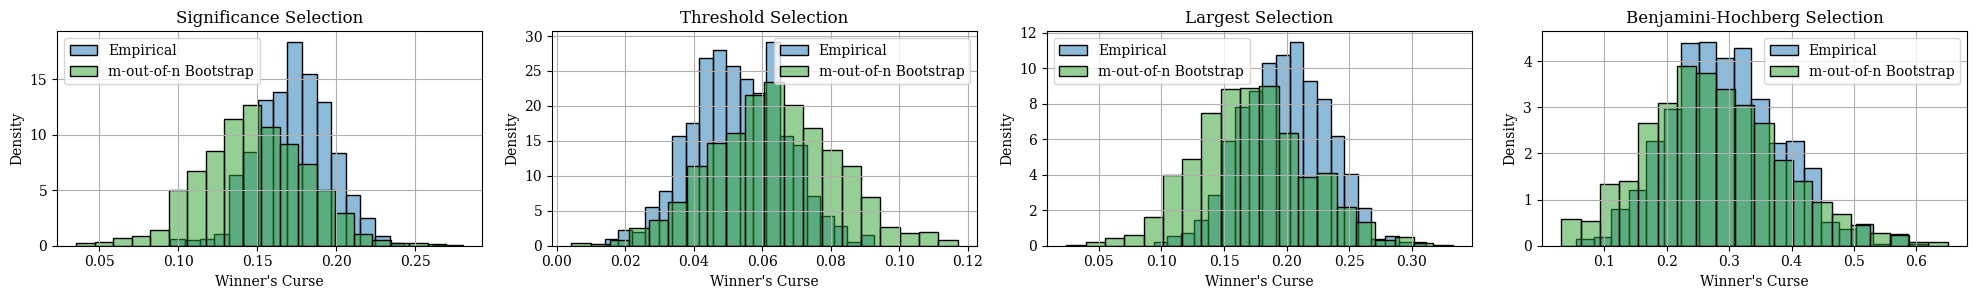

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3.09))

for i, optimizer_name in enumerate(optimization_params.keys()):
    display_name = optimization_params[optimizer_name]['display_name']
    
    wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
    wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

    sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=axes[i])
    sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=axes[i])
    axes[i].set_xlabel('Winner\'s Curse')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{display_name} Selection')
    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [27]:
boot_wc_dstn_dict = rct.get_wc_num_boot_dstn(
    treated_sample=treated_sample, control_sample=control_sample, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, power=-0.45, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


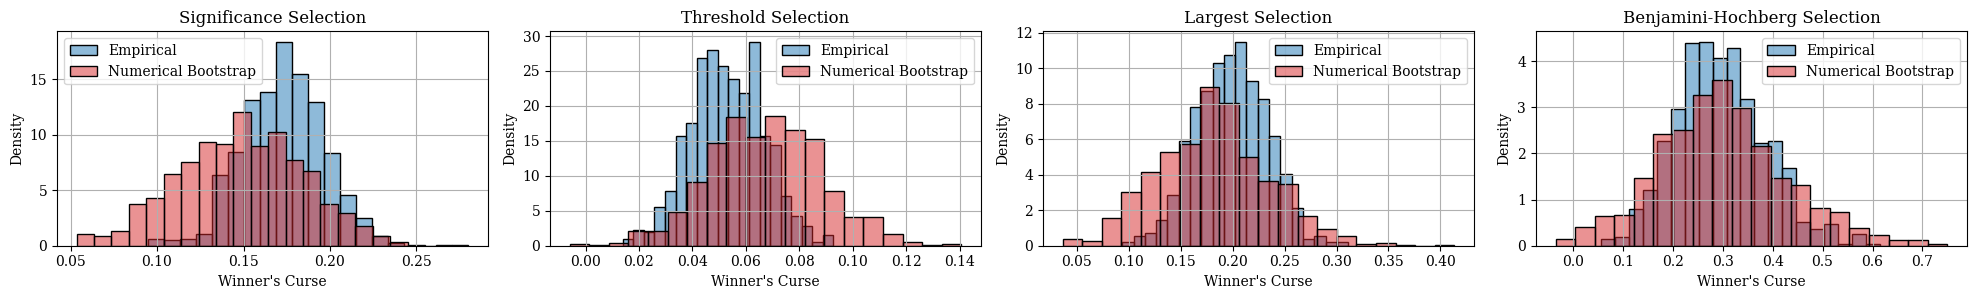

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3.09))

for i, optimizer_name in enumerate(optimization_params.keys()):
    display_name = optimization_params[optimizer_name]['display_name']
    
    wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
    wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

    sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=axes[i])
    sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='Numerical Bootstrap', ax=axes[i])
    axes[i].set_xlabel('Winner\'s Curse')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{display_name} Selection')
    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()

In [29]:
del dgp, treated_sample, control_sample, boot_wc_dstn_dict

# Bias Correction

In [15]:
optimization_params = {
    'significant': {
        'optimizer': rct.select_significant_experiments,
        'params': {}, 
        'display_name': 'Significance'
    }, 
    'threshold': {
        'optimizer': rct.select_above_threshold,
        'params': {'threshold': 0.0},
        'display_name': 'Threshold'
    },
    'largest': {
        'optimizer': rct.select_largest_effects,
        'params': {'k': 0.1},
        'display_name': 'Largest'
    },
    'bh': {
        'optimizer': rct.select_bh,
        'params': {'fdr': 0.05},
        'display_name': 'Benjamini-Hochberg'
    }
}

dgp_params = {
    'n_experiments': 100, 
    'prior_mean': 0.1, 
    'prior_std': 0.1, 
    'noise_std': 1.0, 
    'prior_seed': 0,
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'EB (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }
}

In [16]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   21.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   26.6s finished



Selection with Significance:
  - True Value: 0.1959 (0.0018)
Winner's Curse: 
  - No Correction: 0.1731 (0.0023)
  - Standard Bootstrap: 0.0569 (0.0029)
  - m-out-of-n Bootstrap: 0.0242 (0.0030)
  - Numerical Bootstrap: 0.0266 (0.0031)
  - Bayes (Normal): 0.1660 (0.0023)
  - EB (Normal): 0.0273 (0.0037)
  - EB (Spike-and-Slab): 0.0731 (0.0027)
Sample Splitting: 
  - True Value: 0.1852 (0.0027)
  - Estimated Value: 0.1867 (0.0072)
  - Winner's Curse: 0.0015 (0.0067)


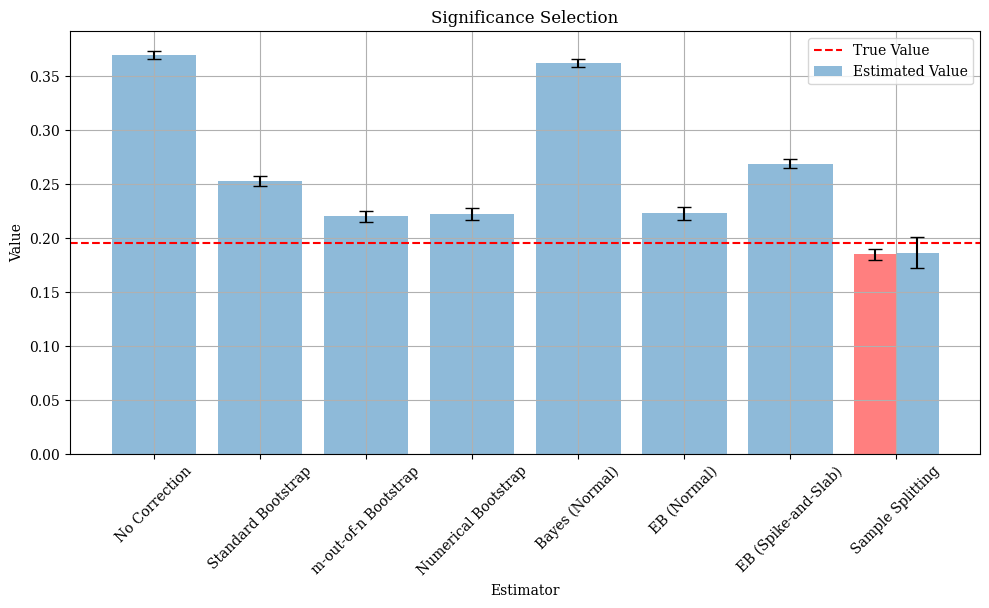


Selection with Threshold:
  - True Value: 0.1329 (0.0006)
Winner's Curse: 
  - No Correction: 0.0531 (0.0014)
  - Standard Bootstrap: 0.0069 (0.0017)
  - m-out-of-n Bootstrap: -0.0038 (0.0017)
  - Numerical Bootstrap: -0.0051 (0.0017)
  - Bayes (Normal): 0.0495 (0.0014)
  - EB (Normal): 0.0100 (0.0018)
  - EB (Spike-and-Slab): 0.0039 (0.0020)
Sample Splitting: 
  - True Value: 0.1302 (0.0006)
  - Estimated Value: 0.1329 (0.0025)
  - Winner's Curse: 0.0027 (0.0024)


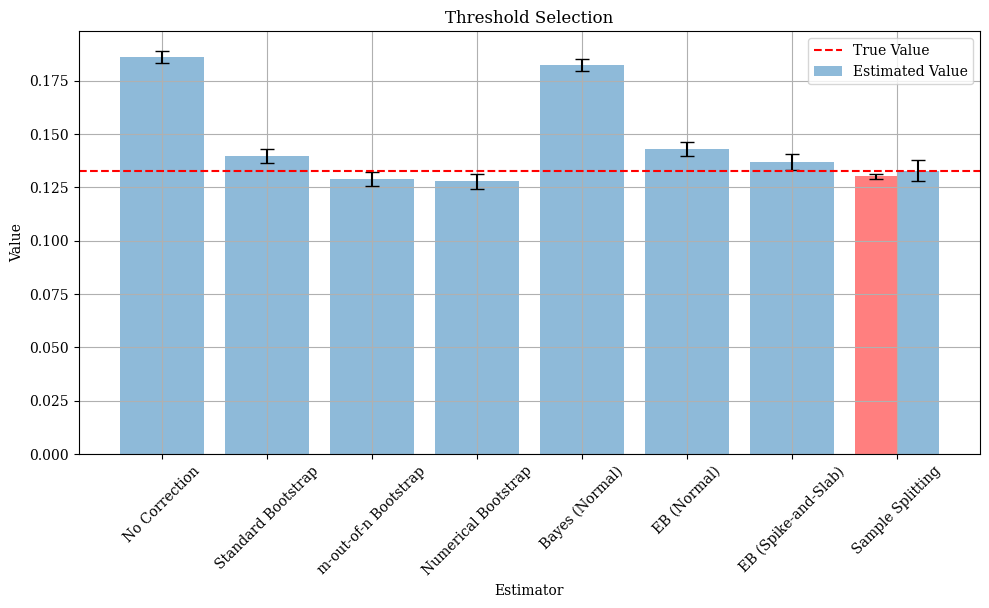


Selection with Largest:
  - True Value: 0.2096 (0.0024)
Winner's Curse: 
  - No Correction: 0.1986 (0.0034)
  - Standard Bootstrap: 0.0461 (0.0041)
  - m-out-of-n Bootstrap: 0.0149 (0.0041)
  - Numerical Bootstrap: 0.0064 (0.0043)
  - Bayes (Normal): 0.1907 (0.0033)
  - EB (Normal): 0.0373 (0.0046)
  - EB (Spike-and-Slab): 0.0874 (0.0036)
Sample Splitting: 
  - True Value: 0.1845 (0.0026)
  - Estimated Value: 0.1850 (0.0067)
  - Winner's Curse: 0.0005 (0.0062)


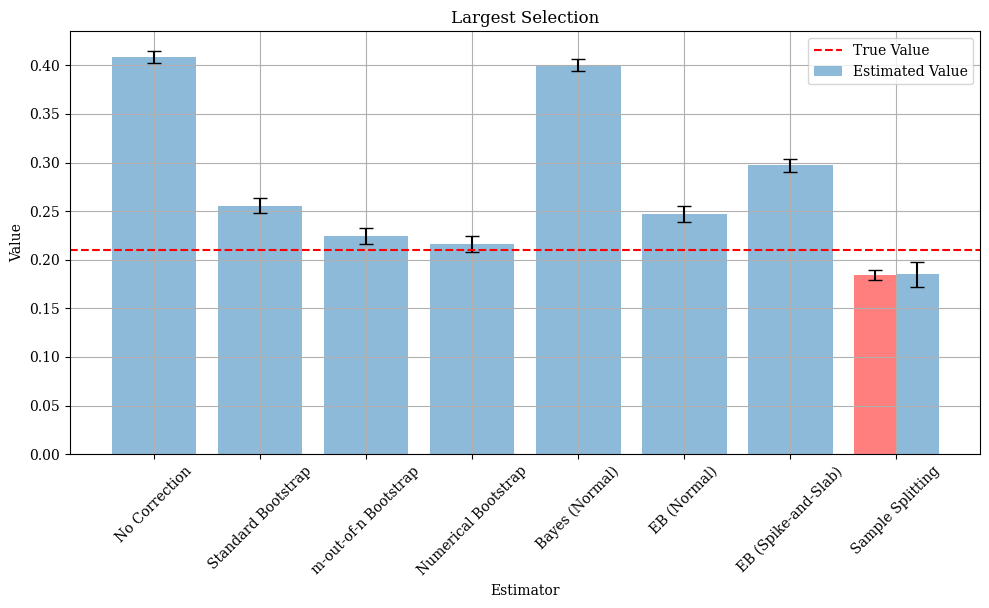


Selection with Benjamini-Hochberg:
  - True Value: 0.2408 (0.0067)
Winner's Curse: 
  - No Correction: 0.2969 (0.0091)
  - Standard Bootstrap: 0.2016 (0.0088)
  - m-out-of-n Bootstrap: 0.0953 (0.0053)
  - Numerical Bootstrap: 0.0783 (0.0118)
  - Bayes (Normal): 0.2868 (0.0090)
  - EB (Normal): 0.1166 (0.0088)
  - EB (Spike-and-Slab): 0.1476 (0.0081)
Sample Splitting: 
  - True Value: 0.2085 (0.0082)
  - Estimated Value: 0.2142 (0.0209)
  - Winner's Curse: 0.0057 (0.0193)


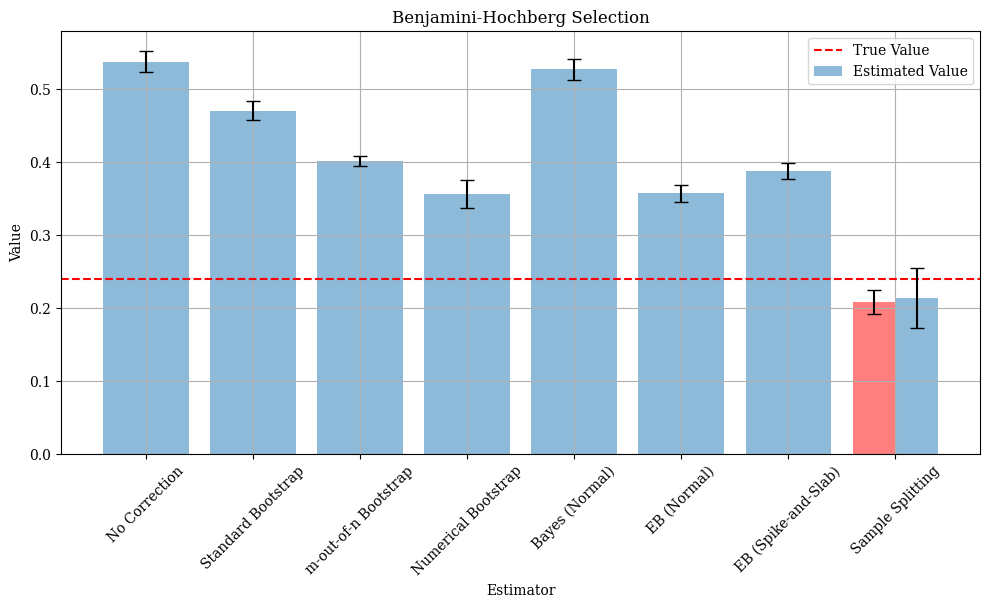

In [17]:
for optimizer_key in optimization_params.keys():
    wc_dict = {}
    val_est_dict = {}

    val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
    val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

    for estimator_key in ['nc'] + list(estimators_dict.keys()):
        if estimator_key == 'sample_splitting':
            continue
        
        estimator_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

        wc_dict.update({
            estimator_name: {
                "Avg. Winners Curse": wc_measures_dict[f'{optimizer_key}_{estimator_key}_wc_avg'],
                "S.E. Winners Curse": wc_measures_dict[f'{optimizer_key}_{estimator_key}_wc_se'],
            }
        })
        val_est_dict.update({
            estimator_name: {
                "Avg. Estimated Value": wc_measures_dict[f'{optimizer_key}_{estimator_key}_val_est_avg'],
                "S.E. Estimated Value": wc_measures_dict[f'{optimizer_key}_{estimator_key}_val_est_se'],
            }
        })

    print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

    print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f"Winner's Curse: ")
    for estimator_name in wc_dict.keys():
        print(f'  - {estimator_name}: {wc_dict[estimator_name]["Avg. Winners Curse"]:.4f} ({wc_dict[estimator_name]["S.E. Winners Curse"]:.4f})')

    if 'sample_splitting' in estimators_dict.keys():
        print(f'Sample Splitting: ')
        ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
        ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
        ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
        ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
        ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
        ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

        print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
        print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
        print(f'  - Winner\'s Curse: {ss_wc_avg:.4f} ({ss_wc_se:.4f})')

    # bar plot comparing the true value and estiamted value frome each estimator 
    fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

    bar_positions = np.arange(len(val_est_dict))
    bar_values = [val_est_dict[estimator_name]["Avg. Estimated Value"] for estimator_name in val_est_dict.keys()]
    bar_errors = [1.95 * val_est_dict[estimator_name]["S.E. Estimated Value"] for estimator_name in val_est_dict.keys()]
        

    # plot the bars
    ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
    ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

    # plot the bar for sample splitting if it exists
    if 'sample_splitting' in estimators_dict.keys():
        # two side-by-side bars for sample splitting, one for true value and one for estimated value
        bar_width = 0.4
        ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
        ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

    ax.set_xlabel('Estimator')
    ax.set_ylabel('Value')
    ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection')
    ax.set_xticks(
        np.arange(len(val_est_dict) + 1), 
        labels=list(val_est_dict.keys()) + ['Sample Splitting'], 
        rotation=45
    )
    ax.legend()
    ax.grid()
    plt.tight_layout()
    plt.show()


## Selection with Threshold

In [18]:
optimization_params = {
    'threshold': {
        'optimizer': rct.select_above_threshold,
        'params': {'threshold': 0.0},
        'display_name': 'Threshold'
    },
}

dgp_params = {
    'n_experiments': 100, 
    'prior_mean': 0.1, 
    'prior_std': 0.1, 
    'noise_std': 1.0, 
    'prior_seed': 0,
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'EB (Normal)'
    },
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'bayes_normal_adj': {
        'estimator': rct.bayes_selection_adjusted_estimate, 
        'params': {
            'selection_threshold': optimization_params['threshold']['params']['threshold'],
            'prior_mean': 0.0, 'prior_std': 1.0
        },
        'display_name': 'Adj. Bayes (Normal)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'selection_threshold': optimization_params['threshold']['params']['threshold'],
            'pi': 0.5
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [19]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  9.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 12.4min finished



Selection with Threshold:
  - True Value: 0.1329 (0.0006)
Winner's Curse: 
  - No Correction: 0.0531 (0.0014)
  - Standard Bootstrap: 0.0069 (0.0017)
  - m-out-of-n Bootstrap: -0.0038 (0.0017)
  - Numerical Bootstrap: -0.0051 (0.0017)
  - Bayes (Normal): 0.0495 (0.0014)
  - EB (Normal): 0.0100 (0.0018)
  - EB (Spike-and-Slab): 0.0039 (0.0020)
  - Adj. Bayes (Normal): -0.1259 (0.0031)
  - Adj. EB (Spike-and-Slab): -0.0305 (0.0019)
Sample Splitting: 
  - True Value: 0.1302 (0.0006)
  - Estimated Value: 0.1329 (0.0025)
  - Winner's Curse: 0.0027 (0.0024)


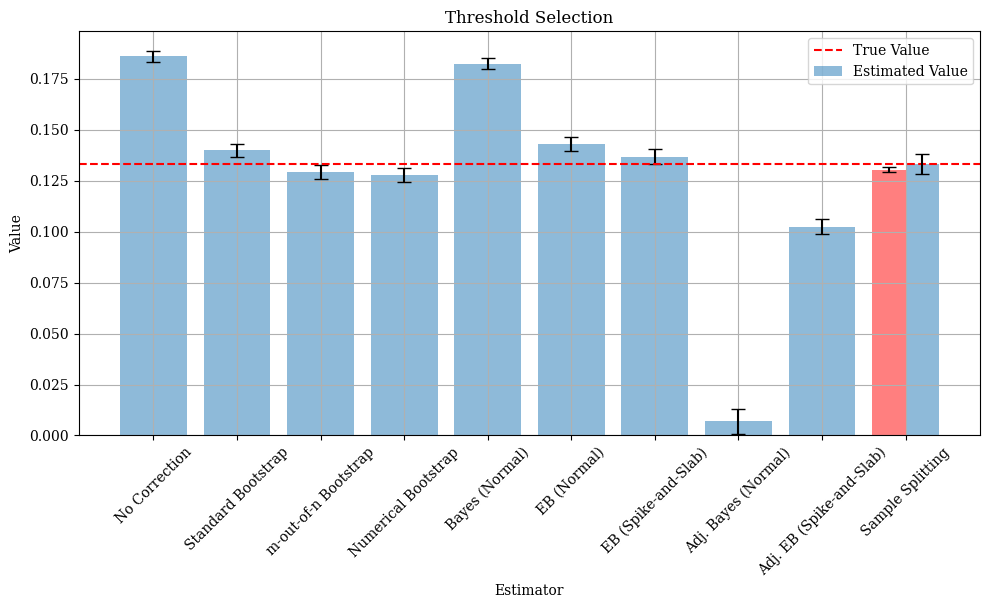

In [20]:
for optimizer_key in optimization_params.keys():
    wc_dict = {}
    val_est_dict = {}

    val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
    val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

    for estimator_key in ['nc'] + list(estimators_dict.keys()):
        if estimator_key == 'sample_splitting':
            continue
        
        estimator_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

        wc_dict.update({
            estimator_name: {
                "Avg. Winners Curse": wc_measures_dict[f'{optimizer_key}_{estimator_key}_wc_avg'],
                "S.E. Winners Curse": wc_measures_dict[f'{optimizer_key}_{estimator_key}_wc_se'],
            }
        })
        val_est_dict.update({
            estimator_name: {
                "Avg. Estimated Value": wc_measures_dict[f'{optimizer_key}_{estimator_key}_val_est_avg'],
                "S.E. Estimated Value": wc_measures_dict[f'{optimizer_key}_{estimator_key}_val_est_se'],
            }
        })

    print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

    print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f"Winner's Curse: ")
    for estimator_name in wc_dict.keys():
        print(f'  - {estimator_name}: {wc_dict[estimator_name]["Avg. Winners Curse"]:.4f} ({wc_dict[estimator_name]["S.E. Winners Curse"]:.4f})')

    if 'sample_splitting' in estimators_dict.keys():
        print(f'Sample Splitting: ')
        ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
        ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
        ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
        ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
        ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
        ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

        print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
        print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
        print(f'  - Winner\'s Curse: {ss_wc_avg:.4f} ({ss_wc_se:.4f})')

    # bar plot comparing the true value and estiamted value frome each estimator 
    fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

    bar_positions = np.arange(len(val_est_dict))
    bar_values = [val_est_dict[estimator_name]["Avg. Estimated Value"] for estimator_name in val_est_dict.keys()]
    bar_errors = [1.95 * val_est_dict[estimator_name]["S.E. Estimated Value"] for estimator_name in val_est_dict.keys()]
        

    # plot the bars
    ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
    ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

    # plot the bar for sample splitting if it exists
    if 'sample_splitting' in estimators_dict.keys():
        # two side-by-side bars for sample splitting, one for true value and one for estimated value
        bar_width = 0.4
        ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
        ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

    ax.set_xlabel('Estimator')
    ax.set_ylabel('Value')
    ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection')
    ax.set_xticks(
        np.arange(len(val_est_dict) + 1), 
        labels=list(val_est_dict.keys()) + ['Sample Splitting'], 
        rotation=45
    )
    ax.legend()
    ax.grid()
    plt.tight_layout()
    plt.show()


# Comparative Statics

## Number of Arms

In [33]:
optimization_params = {
    'threshold': {
        'optimizer': rct.select_above_threshold,
        'params': {'threshold': 0.0},
        'display_name': 'Threshold'
    },
}

dgp_params = {
    'n_experiments': np.nan , 
    'prior_mean': 0.1, 
    'prior_std': 0.1, 
    'noise_std': 1.0, 
    'prior_seed': 0,
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'EB (Normal)'
    },
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'bayes_normal_adj': {
        'estimator': rct.bayes_selection_adjusted_estimate, 
        'params': {
            'selection_threshold': optimization_params['threshold']['params']['threshold'],
            'prior_mean': 0.0, 'prior_std': 1.0
        },
        'display_name': 'Adj. Bayes (Normal)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'selection_threshold': optimization_params['threshold']['params']['threshold'],
            'pi': 0.5
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [35]:
n_arms_list = [10, 25, 50, 75, 100]

num_arms_result_dict = {n_arms: None for n_arms in n_arms_list}

for n_arms in n_arms_list:
    print(f'\nNumber of Experiments = {n_arms}')
    dgp_params['n_experiments'] = n_arms

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    num_arms_result_dict[n_arms] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Number of Experiments = 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   29.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 25
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   54.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 50
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  6.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 75
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  7.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  9.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  9.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 12.4min finished


In [46]:
num_arms_wc_avg_df = pd.DataFrame({
    n_arms: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for n_arms, wc_dict in num_arms_result_dict.items()
}).T / dgp_params['prior_mean'] * 100

num_arms_wc_se_df = pd.DataFrame({
    n_arms: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for n_arms, wc_dict in num_arms_result_dict.items()
}).T / dgp_params['prior_mean'] * 100

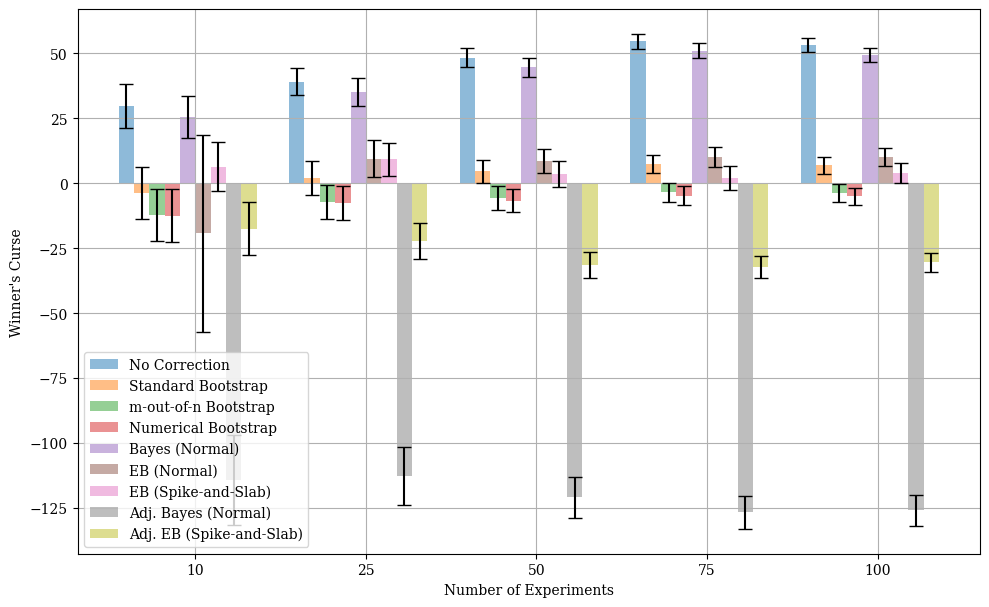

In [53]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

optimizer_key = 'threshold'

n_estimators = len(estimators_dict.keys()) + 1
bar_positions = np.arange(len(num_arms_wc_avg_df.index))
bar_width = 0.09 * n_estimators

# plot the bars
for idx, estimator_key in enumerate(['nc'] + list(estimators_dict.keys())):
    bar_values = num_arms_wc_avg_df[f'{estimator_key}_wc_avg'].values
    bar_errors = 1.95 * num_arms_wc_se_df[f'{estimator_key}_wc_se'].values
    display_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=display_name, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel('Number of Experiments')
ax.set_ylabel('Winner\'s Curse')
ax.set_xticks(
    np.arange(len(num_arms_wc_avg_df.index)), 
    labels=num_arms_wc_avg_df.index, 
)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# Sketch

In [ ]:
dgp_params = {
    'n_experiments': 100, 
    'prior_mean': 0.1, 
    'prior_std': 0.1, 
    'noise_std': 1.0, 
    'prior_seed': 0,
}

optimization_params = {
    'threshold': {
        'optimizer': rct.select_above_threshold,
        'params': {'threshold': 0.0},
        'display_name': 'Threshold'
    },
}

data_params = {'sample_size': 500}

In [ ]:
dgp = RCTs(**dgp_params)
treated_sample, control_sample = dgp.sample(sample_size=data_params['sample_size'], seed=0)

emp_te_arr, _, p_val_arr = rct.difference_in_means(treated_sample, control_sample)
sampling_vars = (treated_sample.var(0) + control_sample.var(0)) / data_params['sample_size']

threshold_selection = rct.select_above_threshold(treatment_effects=emp_te_arr, p_vals=p_val_arr, threshold=0.0)

In [ ]:
eb_post_mean_arr = rct.empirical_bayes_spike_slab(
    mle_treatment_effects=emp_te_arr,
    sampling_vars=sampling_vars,
    pi=0.5, 
    max_iter=100, 
    tol=1e-6,
)

In [ ]:
adj_eb_post_mean_arr = rct.empirical_bayes_spike_slab_selection_adjusted(
    mle_estimates=emp_te_arr, 
    selection=threshold_selection, 
    sample_vars=sampling_vars, 
    threshold=0.0, 
    pi=0.5, 
    max_iter=100, 
    tol=1e-6, 
    epsilon=1e-6
)

In [ ]:
adj_bayes_post_mean_arr = rct.bayes_normal_selection_adjusted(
    mle_estimates=emp_te_arr, 
    selection=threshold_selection, 
    sample_vars=sampling_vars, 
    threshold=0.0, 
    prior_mean=0.0, 
    prior_std=1.0
)

In [ ]:
compare = pd.DataFrame({
    'True Value': dgp.treatment_effects[threshold_selection],
    'Empirical Estimate': emp_te_arr[threshold_selection],
    'Adj. Bayes (Normal)': adj_bayes_post_mean_arr[threshold_selection],
    'Adj. EB (Spike & Slab)': adj_eb_post_mean_arr[threshold_selection]
})
compare.sum()

True Value                 7.967183
Empirical Estimate        11.269625
Adj. Bayes (Normal)       -2.162168
Adj. EB (Spike & Slab)     4.758662
dtype: float64

In [ ]:
optimization_params = {
    'threshold': {
        'optimizer': rct.select_above_threshold,
        'params': {'threshold': 0.0},
        'display_name': 'Threshold'
    },
}

_, val_est_dict = empirical_bayes_selection_adjusted_estimate(
    treated_sample, control_sample, optimization_params, selection_threshold=0.0, pi=0.5, max_iter=100, tol=1e-6
)

{'threshold': 4.758661986956858}